# Images as vectors, continued: the two-dimensional Fourier transform

In [`lecture-5-functions-as-vector.ipynb`](lecture-5-functions-as-vector.ipynb) we treated the parrot bitmap $P$ as a vector in a
huge-dimensional inner-product space, with inner product
$\langle P, Q\rangle = \sum_{m,n} P[m,n]\,Q[m,n]\,\Delta\tau$.

Just as a $2\pi$-periodic function of one variable can be expanded in the orthogonal basis $e^{ikt}$
(the ordinary Fourier series), a two-dimensional array can be expanded in the orthogonal basis of
two-dimensional plane waves

$$
e_{k_1,k_2}[m,n] = \exp\!\Big(2\pi i\Big(\tfrac{k_1 m}{M} + \tfrac{k_2 n}{N}\Big)\Big), \qquad m=0,\dots,M-1,\; n = 0,\dots, N-1.
$$

The coefficients of $P$ in this basis are its **discrete Fourier transform (DFT)**

$$
\hat P[k_1,k_2] = \sum_{m=0}^{M-1}\sum_{n=0}^{N-1} P[m,n]\, e^{-2\pi i (k_1 m/M + k_2 n/N)},
$$

computed in $O(MN\log(MN))$ time by the **Fast Fourier Transform** (`np.fft.fft2`) instead of
$O(M^2N^2)$ by brute force. Exactly as in the epicycles notebook, large $|\hat P[k_1,k_2]|$ means the
image has a strong component at that spatial frequency; keeping only the coefficients of largest
magnitude gives the best low-dimensional approximation of the image -- the same projection idea from
Lecture 4, now in two dimensions.

A subtlety: `np.fft.fft2` returns the zero-frequency (DC, i.e. average brightness) coefficient at
index `[0, 0]`, with frequency increasing and then *wrapping around* to negative frequencies partway
through the array. `np.fft.fftshift` reorders the array so that the zero frequency sits at the
geometric center -- this is what lets us plot the spectrum with the origin of frequency space drawn
where it belongs: in the middle of the picture.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import ipywidgets as widgets
from IPython.display import display
from PIL import Image

plt.rcParams.update({'font.size': 14})

# Accent color used to highlight regions of interest, matching the other
# Lecture 4/5 demos.
accent = '#ff4365'

Image shape (rows, cols): (1285, 1920)


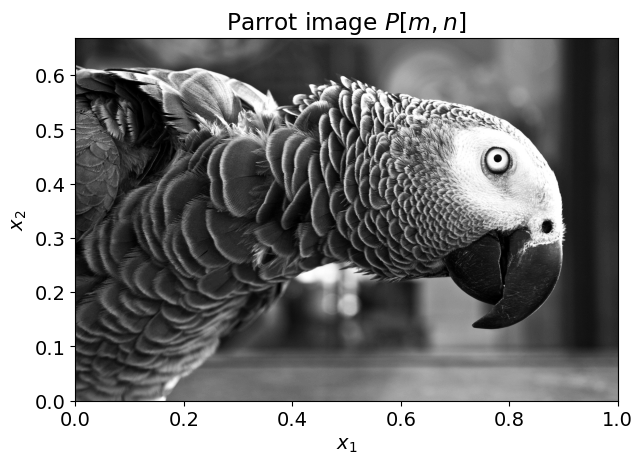

In [8]:
def load_bird(fname):
    """Load a bitmap as a grayscale function P[m, n] with values in [0, 1]."""
    bird = Image.open(fname).convert('L')
    P = np.array(bird, dtype=float) / 255.0
    return P


def show_function(P, title=None, ax=None):
    """Display a grayscale function, matching lecture-5-functions-as-vector.ipynb."""
    if ax is None:
        ax = plt.gca()
    im = ax.imshow(P, extent=(0, 1, 0, P.shape[0] / P.shape[1]), vmin=0, vmax=1, cmap='gray')
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    if title is not None:
        ax.set_title(title)
    return im


P = load_bird('parrot.png')
print('Image shape (rows, cols):', P.shape)

plt.figure(figsize=(7, 5))
show_function(P, title='Parrot image $P[m,n]$')
plt.show()

## Computing and centering the spectrum

`frequency_axes` returns the spatial frequencies (in cycles per pixel) that index each entry of the
*shifted* array, so that entry `[i, j]` of `Fshift` really does correspond to frequency
`(fx[j], fy[i])`. Because $P$ has real pixel values, the spectrum is conjugate-symmetric,
$\hat P[-k_1,-k_2] = \overline{\hat P[k_1,k_2]}$, so positive and negative frequencies carry mirror
information -- another reason it is natural to display them symmetrically around zero.

We plot $\log(1+|\hat P|)$ rather than $|\hat P|$ itself: the DC term (average brightness) dwarfs
everything else on a linear scale, and the log compresses the enormous dynamic range so the fainter,
high-frequency detail becomes visible too.

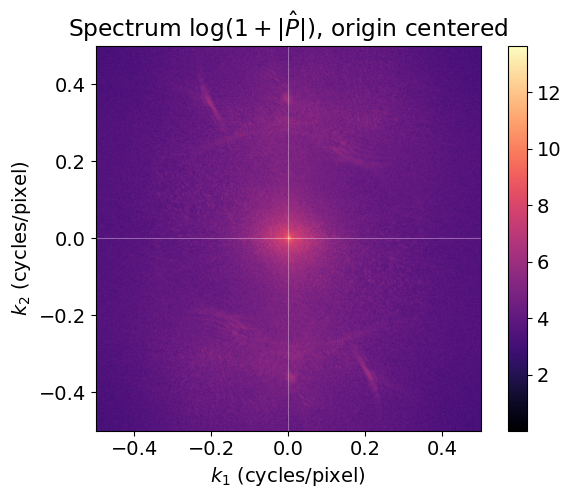

In [9]:
def fourier_transform(P):
    """The 2D DFT of P, with the zero frequency shifted to the center."""
    F = np.fft.fft2(P)
    return np.fft.fftshift(F)


def frequency_axes(P):
    """Cycles-per-pixel frequency axes matching a shifted spectrum of P."""
    rows, cols = P.shape
    fx = np.fft.fftshift(np.fft.fftfreq(cols))  # horizontal frequency, k_1
    fy = np.fft.fftshift(np.fft.fftfreq(rows))  # vertical frequency,   k_2
    return fx, fy


def show_spectrum(Fshift, fx, fy, title=None, ax=None, mark_radius=None):
    """Display log(1+|Fshift|) with frequency zero at the plot's origin."""
    if ax is None:
        ax = plt.gca()
    magnitude = np.log1p(np.abs(Fshift))
    extent = (fx[0], fx[-1], fy[0], fy[-1])
    im = ax.imshow(magnitude, extent=extent, origin='lower', cmap='magma')
    ax.axhline(0, color='white', lw=0.6, alpha=0.4)
    ax.axvline(0, color='white', lw=0.6, alpha=0.4)
    if mark_radius is not None:
        ax.add_patch(Circle((0, 0), mark_radius, fill=False, edgecolor=accent, lw=2))
    ax.set_xlabel(r'$k_1$ (cycles/pixel)')
    ax.set_ylabel(r'$k_2$ (cycles/pixel)')
    if title is not None:
        ax.set_title(title)
    return im


Fshift = fourier_transform(P)
fx, fy = frequency_axes(P)

plt.figure(figsize=(7, 5))
im = show_spectrum(Fshift, fx, fy, title=r'Spectrum $\log(1+|\hat P|)$, origin centered')
plt.colorbar(im)
plt.show()

A few features are visible immediately:

- A bright dot exactly at the origin: the DC term, i.e. the average brightness of the whole image.
- Energy falls off with distance from the origin: like most natural images, $P$ is dominated by
  smooth, slowly varying regions (low frequency), with comparatively little sharp detail (high
  frequency).
- A faint bright cross through the origin, caused by the image's edges: the DFT implicitly treats
  $P$ as *periodic*, so the mismatch between the left/right and top/bottom edges of the picture looks
  like a sharp horizontal/vertical discontinuity and spreads energy along the axes.

## Sanity check: no information was lost

`fourier_transform`/inverse is just a change of basis -- an *orthogonal* one, in fact -- so we should
recover $P$ exactly (up to floating-point round-off) by inverting the shift and applying the inverse
DFT.

Max reconstruction error: 1.6653345369377348e-15


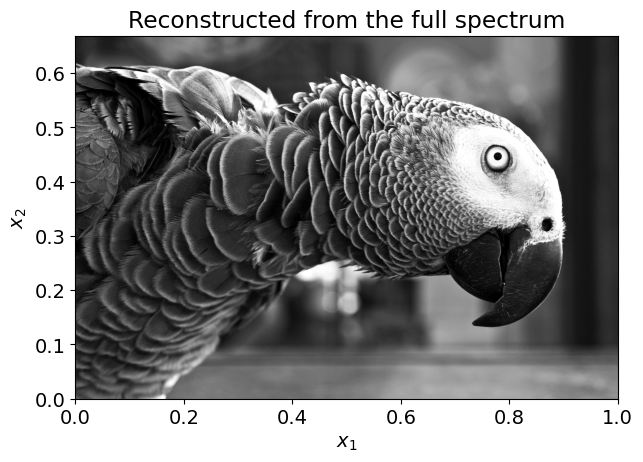

In [10]:
def inverse_fourier_transform(Fshift):
    """Invert fourier_transform: undo the shift, then the inverse DFT."""
    F = np.fft.ifftshift(Fshift)
    return np.fft.ifft2(F).real


P_reconstructed = inverse_fourier_transform(Fshift)
print('Max reconstruction error:', np.max(np.abs(P_reconstructed - P)))

plt.figure(figsize=(7, 5))
show_function(P_reconstructed, title='Reconstructed from the full spectrum')
plt.show()

## Truncating the spectrum: a low-pass filter is a blur

Exactly as truncating a 1D Fourier series to its low-order terms gives the best few-term
approximation of a function, keeping only the coefficients $\hat P[k_1,k_2]$ within a disk
$k_1^2+k_2^2 \le r^2$ around the origin -- and setting every coefficient outside that disk to zero --
gives the best rank-limited approximation of the image *in the Fourier basis*. Sharp edges and fine
texture live at high spatial frequency, so discarding them is precisely what a **blur** is.

The disk is centered at the origin because "low frequency" means "small $|(k_1,k_2)|$", regardless of
direction -- which is exactly why we took care above to place the origin of frequency space at the
center of the array.

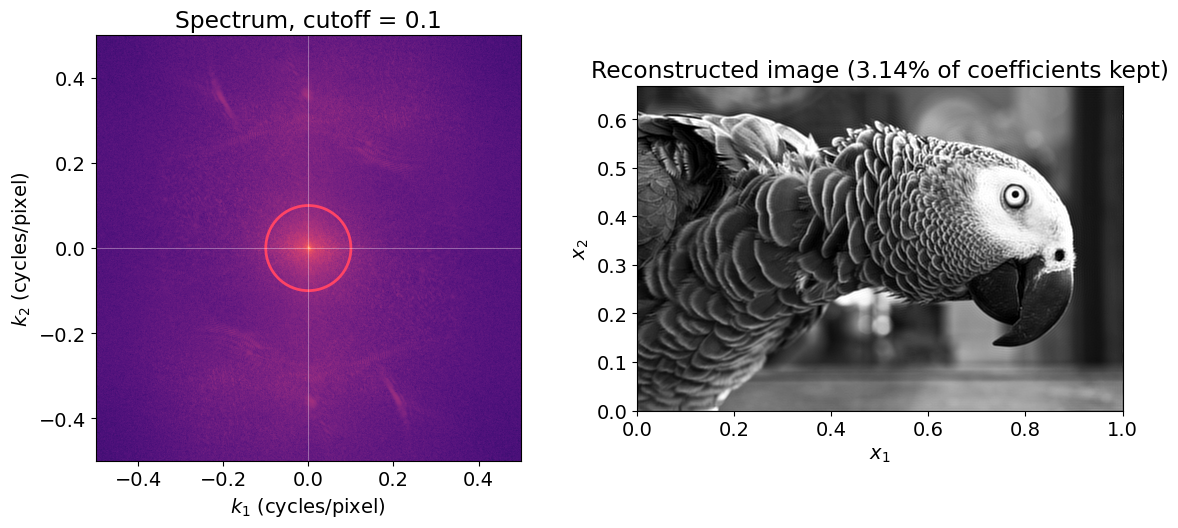

In [12]:
def low_pass_mask(fx, fy, cutoff):
    """Boolean mask, True inside the disk k_1^2 + k_2^2 <= cutoff^2."""
    FX, FY = np.meshgrid(fx, fy)
    return (FX**2 + FY**2) <= cutoff**2


def low_pass_filter(Fshift, fx, fy, cutoff):
    """Zero out every Fourier coefficient outside radius `cutoff` (cycles/pixel)."""
    mask = low_pass_mask(fx, fy, cutoff)
    return Fshift * mask


cutoff = 0.1
Fshift_lp = low_pass_filter(Fshift, fx, fy, cutoff)
P_blur = inverse_fourier_transform(Fshift_lp)
kept = np.count_nonzero(low_pass_mask(fx, fy, cutoff))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
show_spectrum(Fshift, fx, fy, ax=axes[0], mark_radius=cutoff,
              title=f'Spectrum, cutoff = {cutoff}')
show_function(P_blur, ax=axes[1],
              title=f'Reconstructed image ({100 * kept / P.size:.2f}% of coefficients kept)')
plt.tight_layout()
plt.show()

## Interactive: sweep the cutoff radius

Drag the slider to shrink the disk of retained frequencies and watch the image lose detail exactly
outside-in -- large-scale shapes survive even a very aggressive cutoff, while fine texture and edges
are the first casualties.

In [ ]:
def show_lowpass_demo(cutoff):
    Fshift_lp = low_pass_filter(Fshift, fx, fy, cutoff)
    P_blur = inverse_fourier_transform(Fshift_lp)
    kept = np.count_nonzero(low_pass_mask(fx, fy, cutoff))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    show_spectrum(Fshift, fx, fy, ax=axes[0], mark_radius=cutoff,
                  title='Spectrum, retained disk outlined')
    show_function(P_blur, ax=axes[1],
                  title=f'Reconstructed image ({100 * kept / P.size:.2f}% of coefficients kept)')
    plt.tight_layout()
    plt.show()


cutoff_slider = widgets.FloatLogSlider(
    value=0.5, base=10, min=-2.7, max=np.log10(0.5), step=0.02,
    description='cutoff', readout_format='.4f', continuous_update=False,
)

lowpass_output = widgets.interactive_output(show_lowpass_demo, {'cutoff': cutoff_slider})
display(widgets.VBox([cutoff_slider, lowpass_output]))

## What to notice

- An image is a vector, and `np.fft.fft2` expresses it in the orthogonal basis of 2D plane waves
  $e^{i(k_1 x_1 + k_2 x_2)}$ -- the same idea as the complex Fourier series in the epicycles notebook,
  just with two independent frequencies instead of one.
- `np.fft.fftshift` is bookkeeping, not mathematics: it only reorders the array so that the zero
  frequency -- the true origin of frequency space -- lands in the middle of the picture instead of the
  corner.
- Keeping only the Fourier coefficients inside a disk around the origin and discarding the rest is a
  best rank-limited approximation of the image in this basis -- and that approximation *is* a blur,
  since fine detail lives at high spatial frequency.
- At intermediate cutoffs the reconstruction develops ripples instead of a clean blur: a *sharp*
  cutoff in frequency space is itself a discontinuous function of $(k_1,k_2)$, and truncating a series
  at a discontinuity produces the same overshoot/ringing as the 1D **Gibbs phenomenon** -- try the
  slider around cutoff $\approx 0.02$ to see it clearly.
- This is the frequency-domain counterpart of the pixel-domain blurring kernel from
  `lecture-1-blurring.ipynb`: both suppress high spatial frequencies, one by direct convolution, the
  other by explicit truncation of the spectrum.

$$
\boxed{\text{blurring} = \text{truncating the Fourier series of an image}}
$$